In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [2]:
# define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [3]:
# def cal_IBM(state : BMIState) -> BMIState:
#     bmi = state["weight_kg"] / (state["height_m"]**2)
#     state["BMI"] = round(bmi, 2)

def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

In [4]:
def lable_bmi(state : BMIState) -> BMIState:
    bmi = state["bmi"]

    if(bmi < 18.5):
        state["category"] = "Underweight"
    elif(bmi >= 18.5 and bmi < 25):
        state["category"] = "normal"
    elif(bmi >= 25 and bmi < 30):
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"
    return state

In [5]:
# define your graph
graph = StateGraph(BMIState)

graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("lable_bmi", lable_bmi)

# add edges to your graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "lable_bmi")
graph.add_edge("lable_bmi", END)

# compile the graph
workflow = graph.compile()

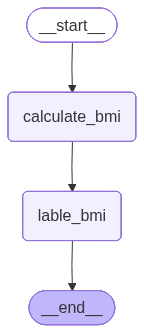

In [6]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [7]:
# execute the graph
intial_state = {'weight_kg':80, 'height_m':1.73}

final_state = workflow.invoke(intial_state)
print(final_state['category'])

Overweight
